# 5G-22 충실 재현 — 리포트 (Rényi-entropy adaptive integration)

*자동 생성: `renyi/build_report.py`. 그림은 base64 내장 — 커널 없이 바로 보입니다.*

**원칙:** 충실(논문 eq/param) · 단계 게이트(각 phase가 figure로 자기증명 후 다음) · viz-first. 논문 Sec 6이 그 자체로 합성 시뮬이라 **Phase A–C는 RT 없이 로컬 재현**, Phase D(Sec 7 실비행)만 Sionna RT. 충실/비충실 정직 구분: `docs/FAITHFULNESS.md`.

## Phase A — content-dependency (논문 Fig 8)

**Gate: ✅ PASS** — CAF target SCR rises with content fill (more occupied REs -> more echo energy / integration gain); low-content buried, high-content detected (Fig 8). Power-vs-content decoupling is quantified in Phase B.

콘텐츠(자원 점유)가 늘수록 CAF 표적 SCR↑ → 저콘텐츠 묻힘, 고콘텐츠 검출. 전력 vs 콘텐츠 분리는 Phase B에서 정량화.

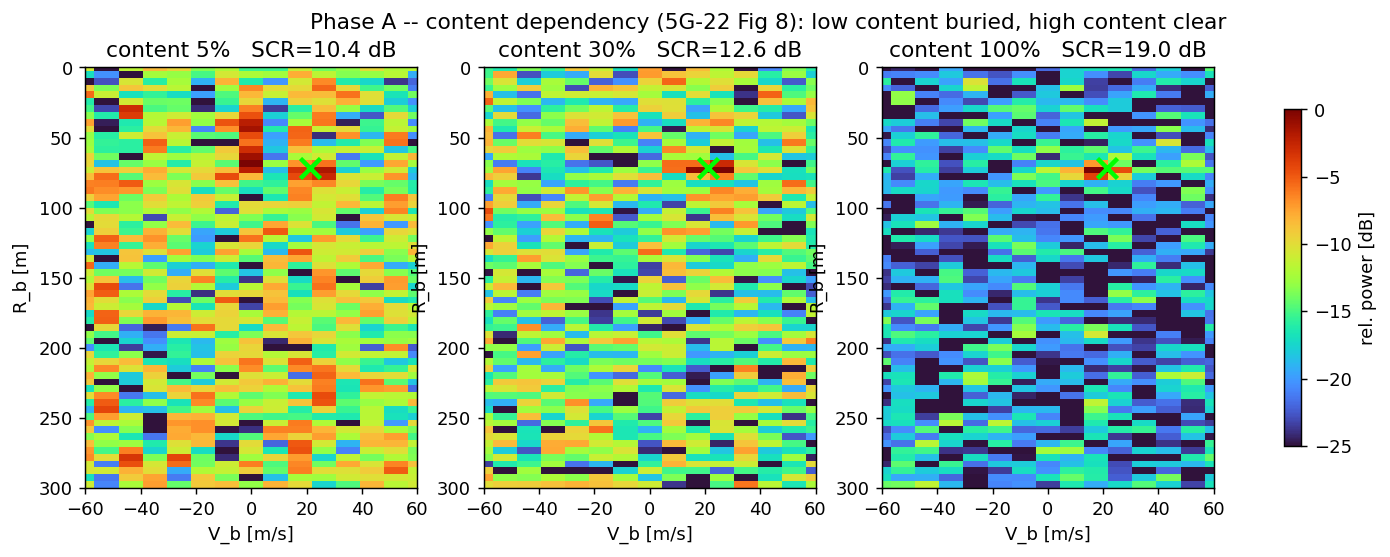

## Phase B — entropy가 power·B_eff를 이김 (논문 Fig 9/11/13)

**Gate: ✅ PASS** — 

Rényi entropy는 fill에 단조·SNR robust; power(Fig 10)와 B_eff(Fig 11)는 콘텐츠를 구분 못함(동일 전력이라도 entropy는 콘텐츠로 분리).

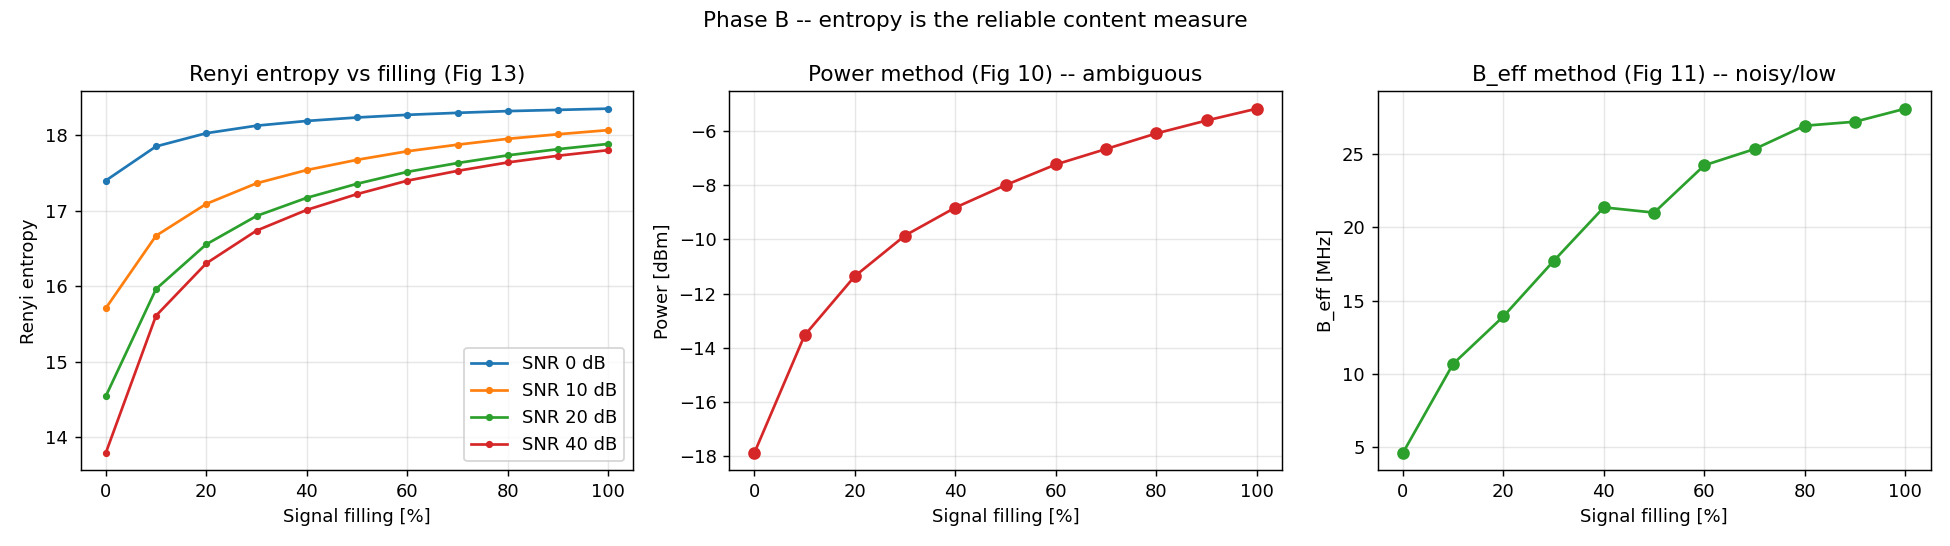

## Phase C — adaptive integration → P_d (논문 Fig 14/15-17)

**Gate: ✅ PASS** — P_d rises with content fill -> selecting high-entropy (dense) frames raises P_d

fill이 클수록 P_d↑ (Pfa {1e-4,1e-6,1e-8}). 고-entropy(밀집) 프레임 선택 = 유효 T_int↑ → 검출 범위↑ (range eq Fig 14).

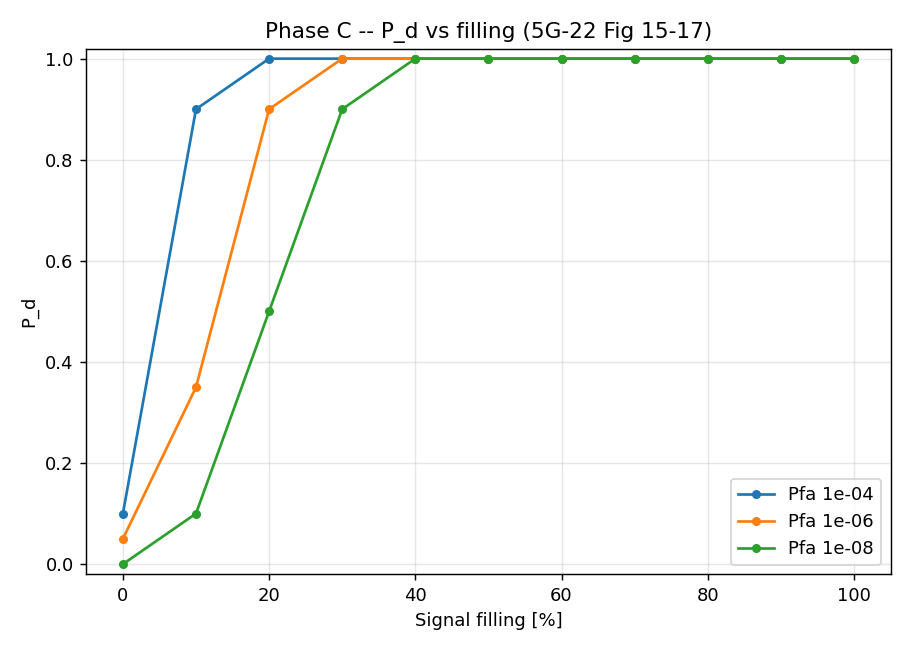

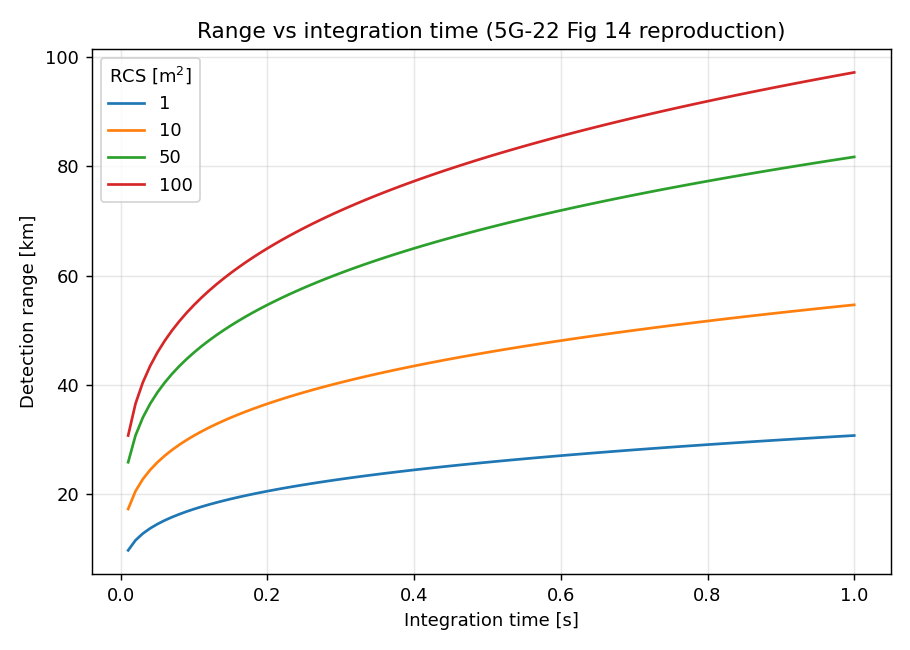

## Phase D — 실비행 bistatic (Sionna RT) (논문 Fig 18/20/21-23)

**Gate: ✅ PASS** — Real Sionna-RT bistatic flight: CFAR detections track the exact GT trajectory; 100 ms integration sharpens velocity vs 20 ms (Fig 21->22); Renyi-entropy selection keeps dense frames that detect where equal-length sparse frames are buried (Sec 5.2).

Phase A–C의 **해석적 echo를 Sionna RT 실제 bistatic 채널로 교체**: gNB 송신·수동 수신·드론 산란체 + 지면 클러터를 광선추적 → 실제 멀티패스. 같은 CAF+CA-CFAR+Rényi 선택 DSP로 처리하고 **Sionna의 정확한 GT**에 검출을 겹쳐 검증.

**핵심 수치** — 검출률 1.0×100% (9/9 waypoint), 거리오차(중앙값) 1.0 m, 속도오차 0.74 m/s · T_int 속도해상도 4.36→0.87 m/s (20→100 ms) · entropy 선택: dense 검출=True, sparse 매몰=True · RT 실행 13.0s

### 📊 한눈에 보기 — Phase D 요약 대시보드
장면·검출·엔트로피 선택·궤적·속도 선명화를 한 장에. (세부는 D1–D6)

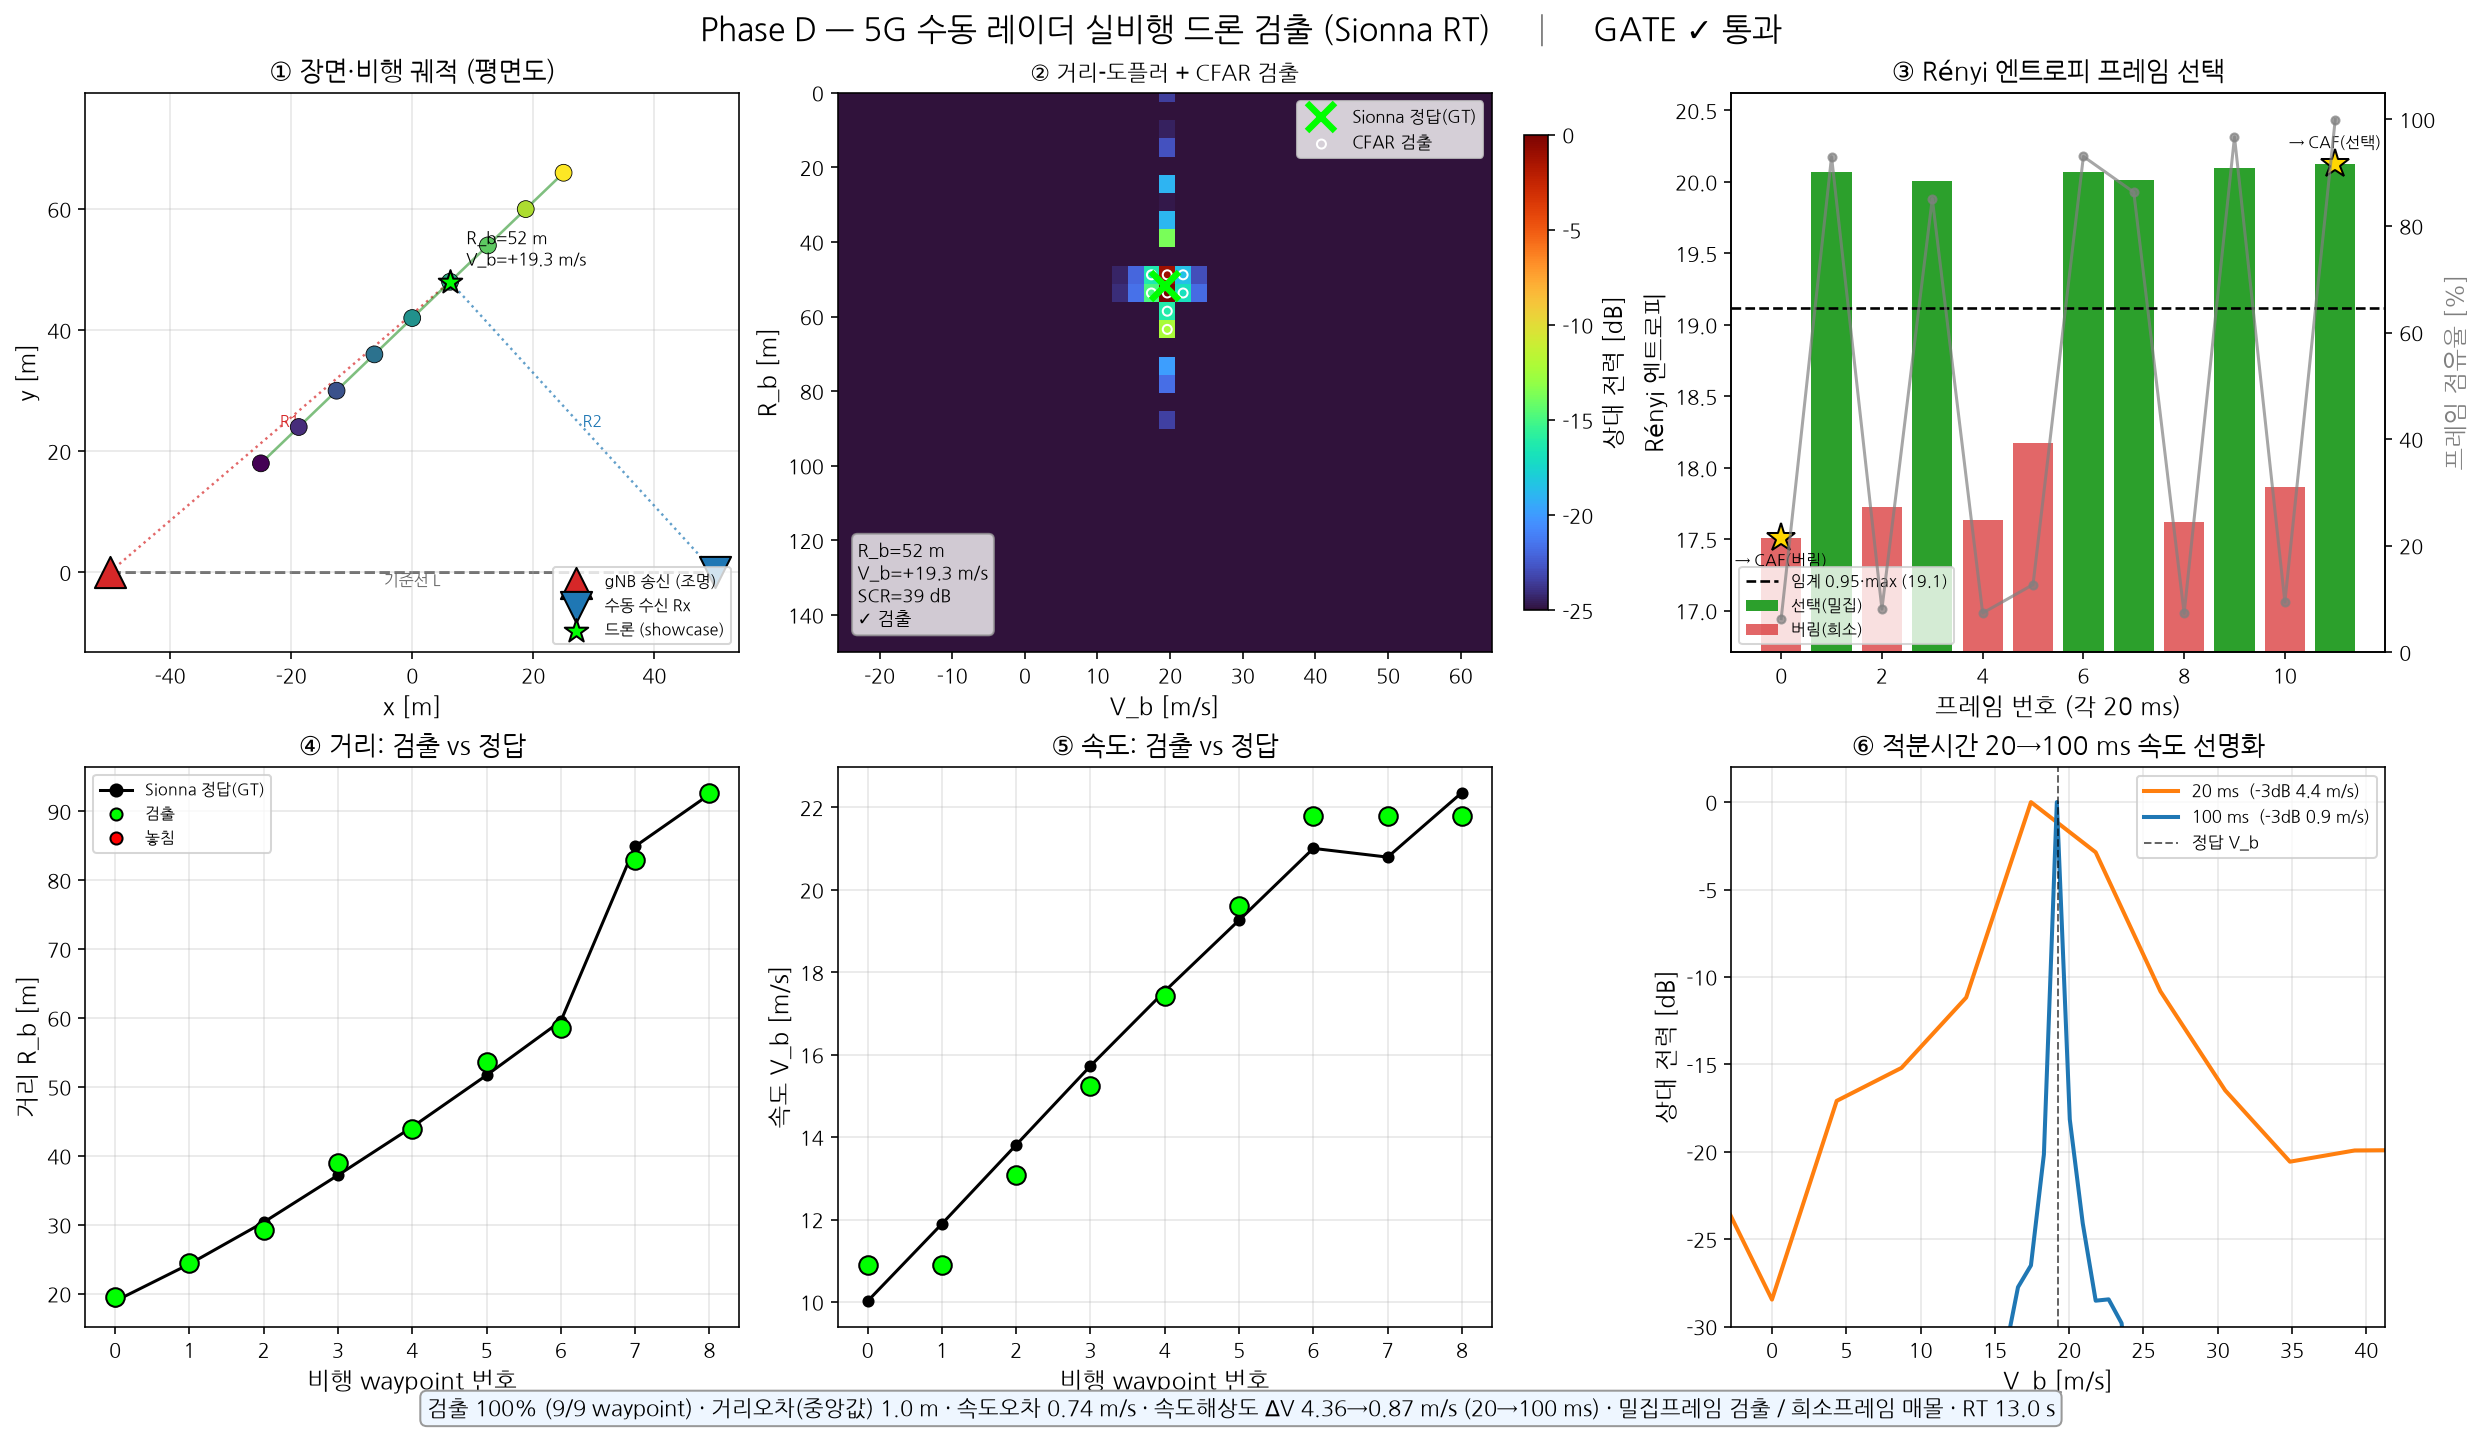

### D1 · bistatic 장면 + 비행 궤적 (Fig 18)
gNB(송신)·수동 Rx·드론 궤적의 3D 기하. baseline L과 showcase waypoint의 LOS 표시.

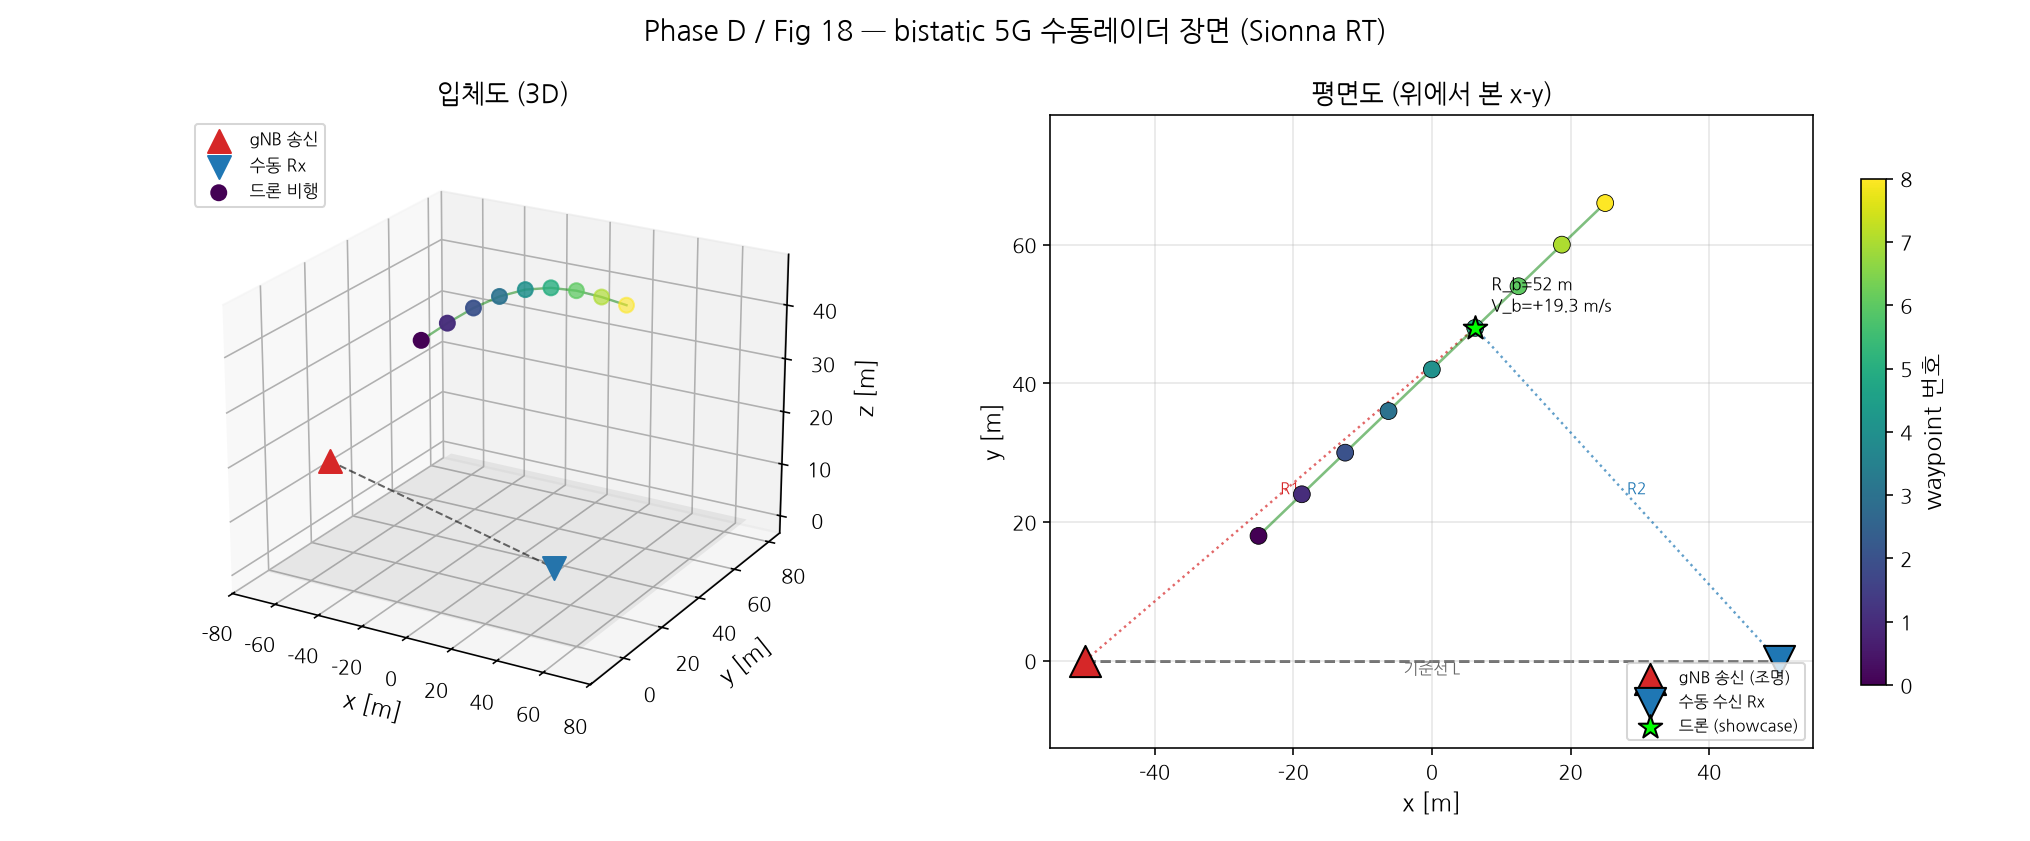

### D2 · 광선추적 채널 (Fig 20)
왼쪽: 채널 임펄스응답 — 드론 echo는 직접파 클러터보다 ~50 dB 아래(→ 클러터 제거 필요). 오른쪽: 경로별 지연-도플러 — 움직이는 경로는 드론뿐(max |f_D|).

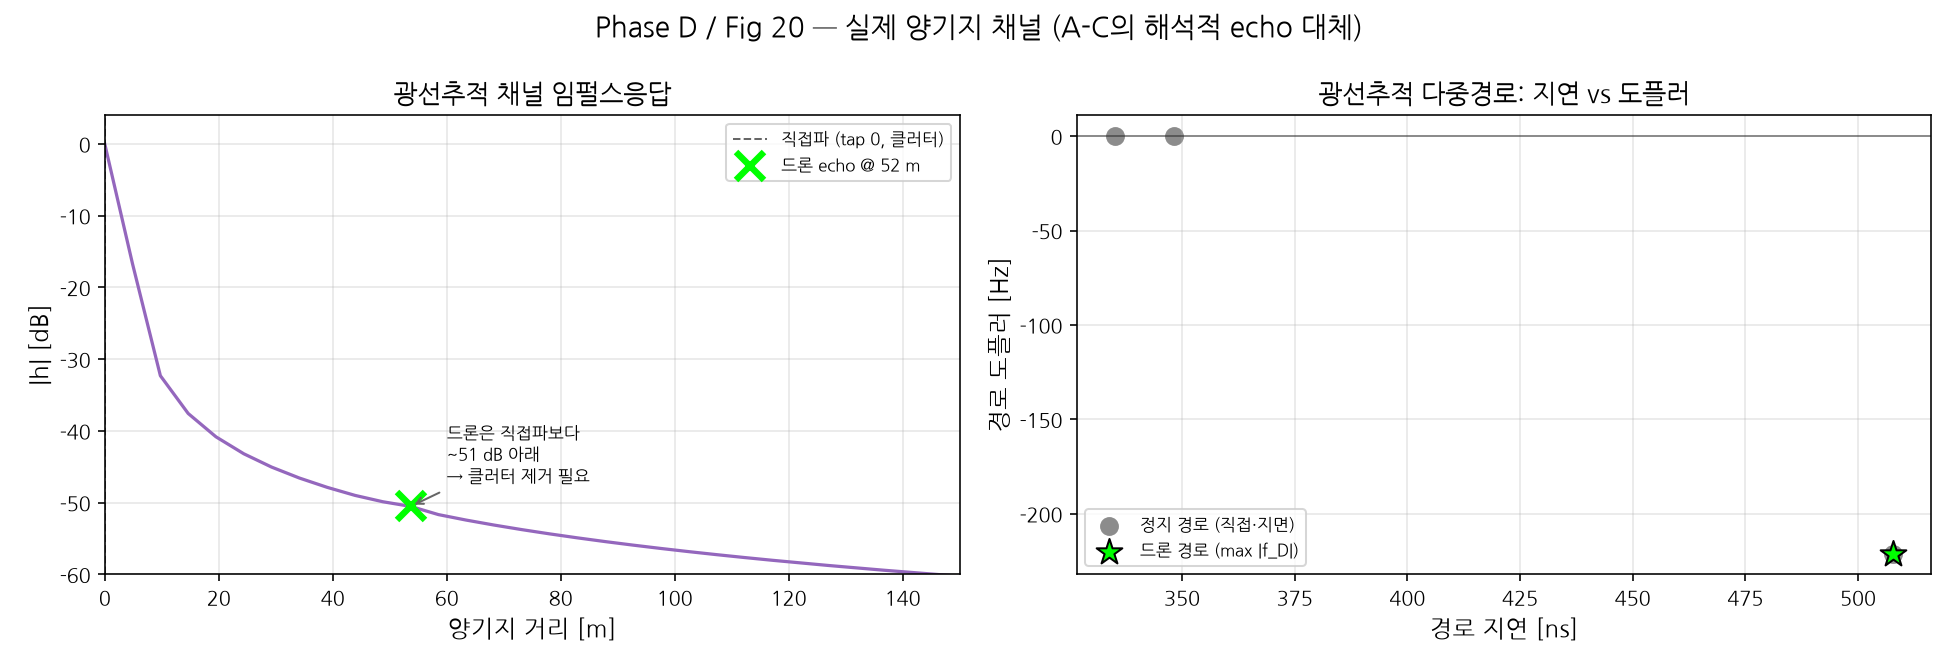

### D3 · 단일 스냅샷 RD + CA-CFAR (Fig 21)
RT echo의 range-Doppler 맵. CFAR 검출(흰 원)이 Sionna GT(녹색 X)에 일치.

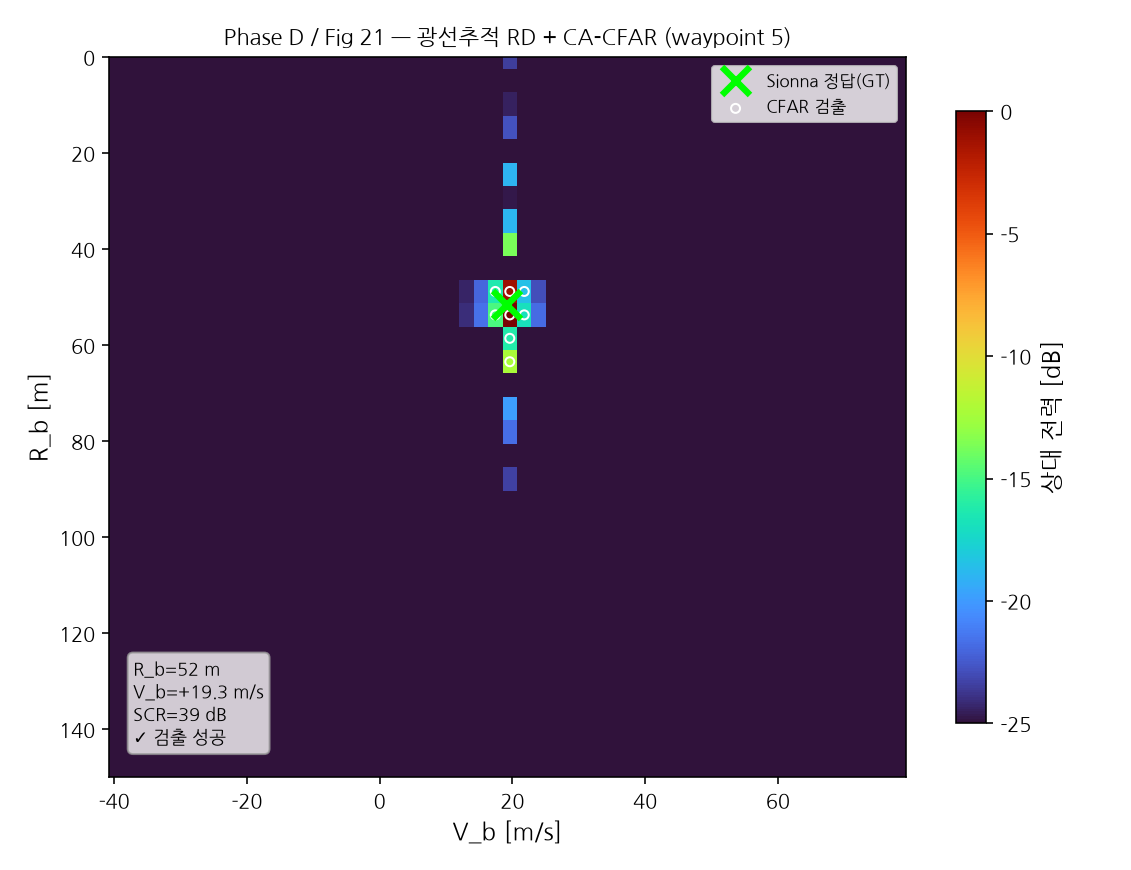

### D4 · 검출 vs Sionna GT 궤적 (Fig 23)
각 waypoint의 CFAR 검출(GT 최근접)이 정확한 GT 거리·속도 곡선을 추적. 전부 hit(녹색).

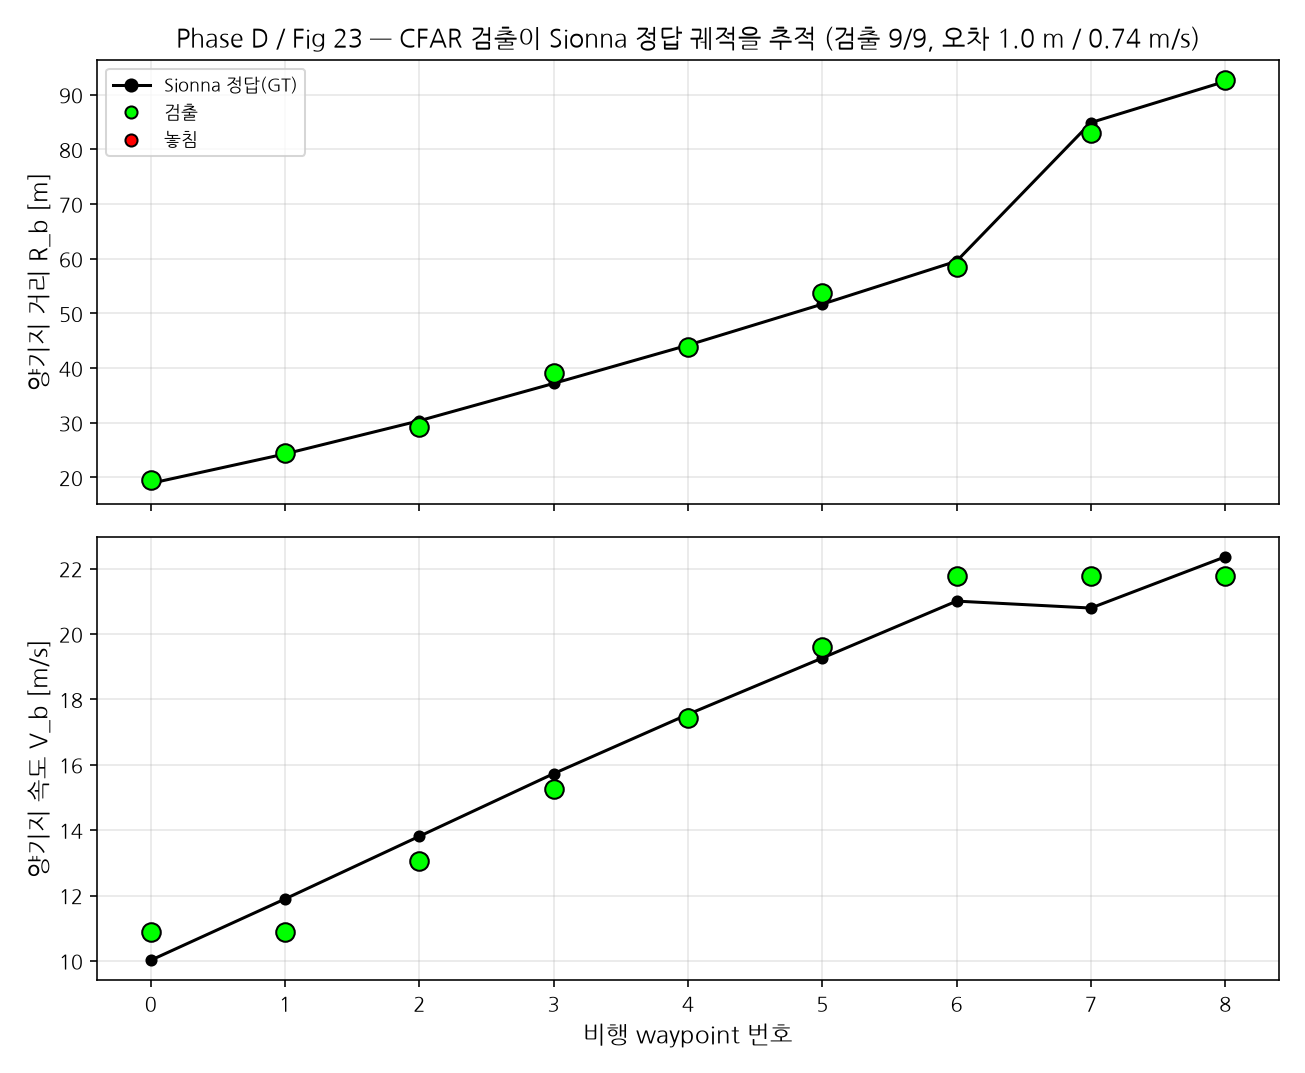

### D5 · T_int 20 ms → 100 ms 속도 선명화 (Fig 21→22)
적분시간이 길수록 도플러(속도) 해상도↑: 20 ms는 넓게 번지고 100 ms는 날카로운 단일 피크. 우측 속도 컷이 -3 dB 폭 축소를 정량화.

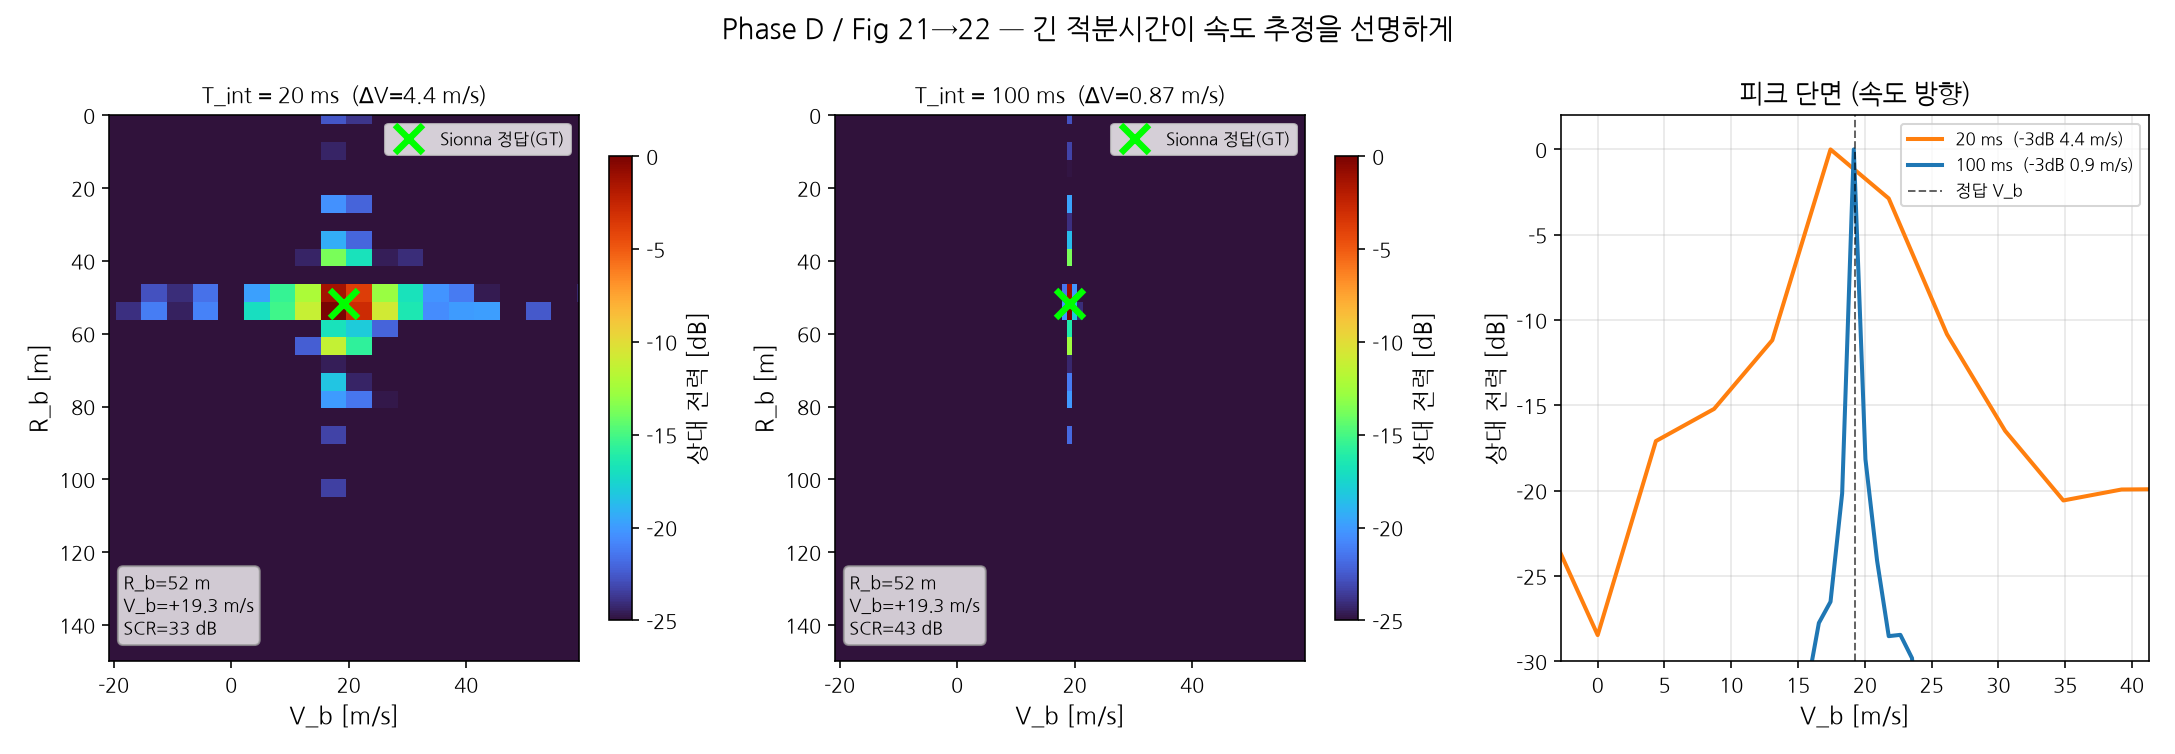

### D6 · Rényi 적응 적분 (novelty, Fig 24)
왼쪽: 프레임별 Rényi entropy로 밀집 프레임 선택(threshold=0.9·max). 오른쪽: **같은 RT 채널**에서 동일 길이라도 dense CPI는 검출, sparse CPI는 매몰 → 왜 dense 프레임을 골라야 하는지(유효 T_int 최대화) 실데이터로 입증.

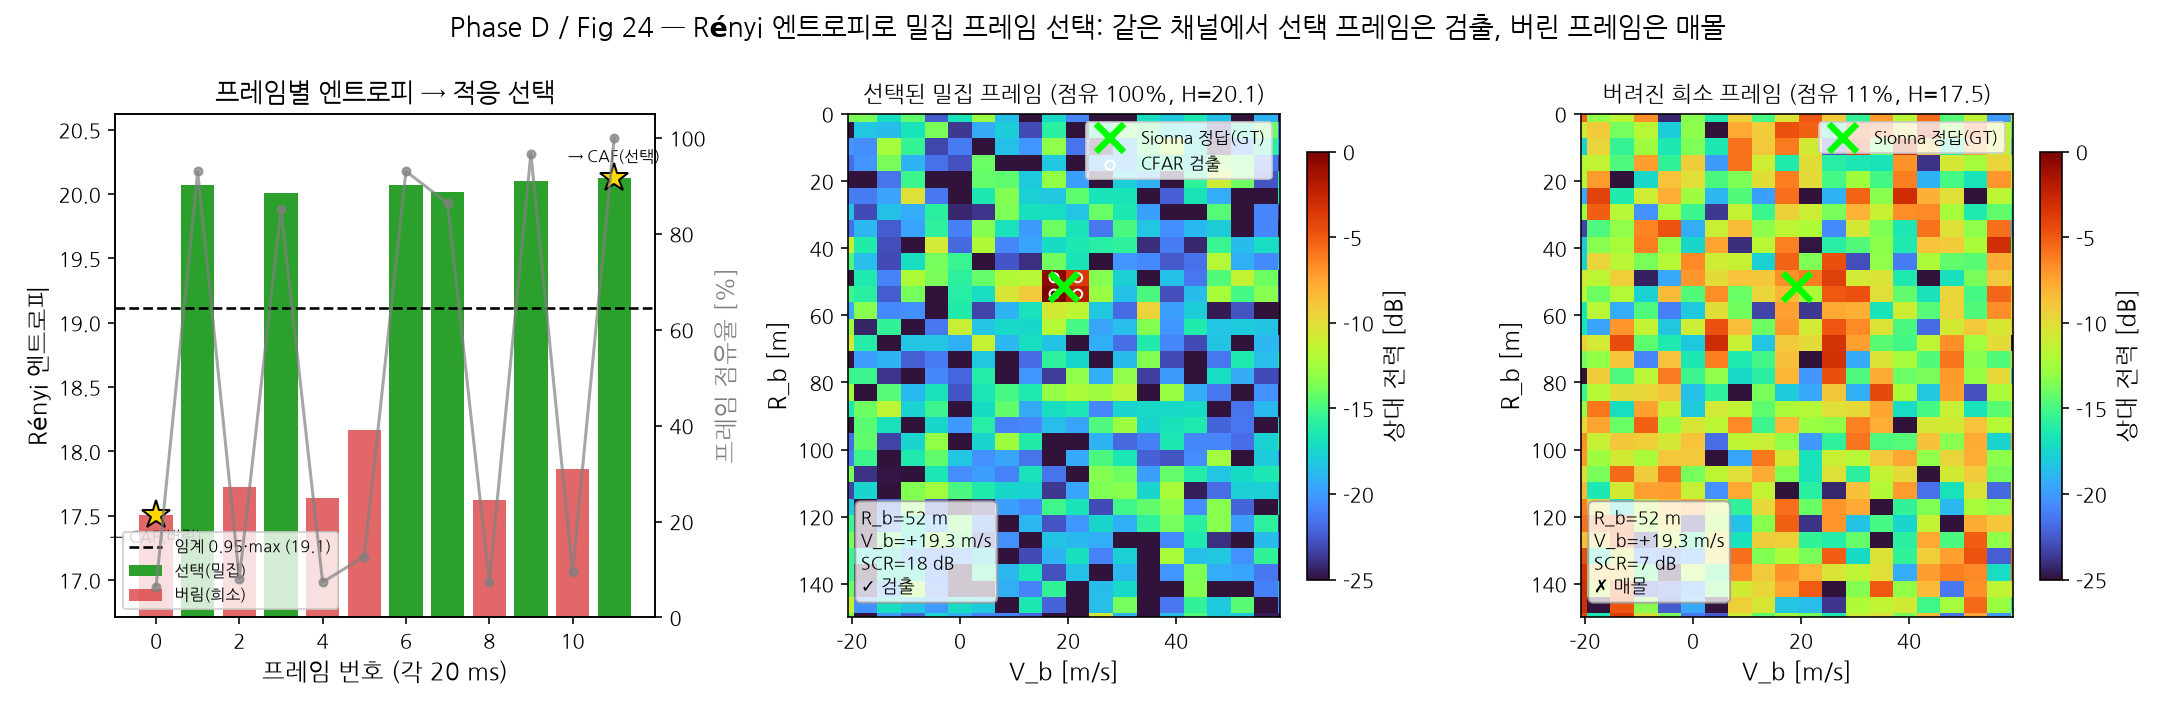